# mexari – Municipalities Graph Visualization
Explore the spatio-temporal NetworkX graph of Mexican municipalities built with the `mexari` package.

## 1 · Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import mexari as mx

print(f"mexari version : {mx.__version__}")
print(f"Bundled CSV    : {mx.DEFAULT_CSV}")

mexari version : 0.1.0
Bundled CSV    : /home/amilan/Insync/alessandromilanortega@outlook.com/OneDrive/Documents/UASLP/PhD/Graph-ARI/mexari/data/mortality_rates.csv


## 2 · Build the graph from a local GeoJSON

In [2]:
# Update this path to point to your local municipalities GeoJSON file.
geojson_path = Path("../Data/mexico.geojson")

if not geojson_path.exists():
    raise FileNotFoundError(
        f"Set `geojson_path` to a local GeoJSON file before running the notebook: {geojson_path}"
    )

G = mx.build_graph(geojson_path=geojson_path)

print(f"Nodes   : {G.number_of_nodes()}")
print(f"Edges   : {G.number_of_edges()}")
print(f"Dates   : {len(G.graph['dates'])}")
print(f"Density : {nx.density(G):.5f}")

Nodes   : 2475
Edges   : 7246
Dates   : 1148
Density : 0.00237


In [ ]:
# Inspect a sample node
sample = G.nodes[24028]
print("Node '24028' attributes:")
for k, v in sample.items():
    if k in ("mortality", "features"):
        print(f"  {k}: {type(v).__name__} with {len(v)} entries")
    else:
        print(f"  {k}: {v}")

Node '24028' attributes:
  municipality: San Luis Potosí
  state: San Luis Potosí
  longitude: -100.96088854094015
  latitude: 22.270479240162825
  mortality: dict with 1148 entries
  features: ndarray with 1148 entries


## 3 · Basic graph statistics

In [28]:
degrees = dict(G.degree())
deg_series = pd.Series(degrees, name="degree")

print("Degree statistics")
print(deg_series.describe().round(2))
print(f"\nConnected components : {nx.number_connected_components(G)}")
print(f"Avg clustering coeff : {nx.average_clustering(G):.4f}")

Degree statistics
count    2475.00
mean        5.86
std         2.21
min         1.00
25%         4.00
50%         6.00
75%         7.00
max        22.00
Name: degree, dtype: float64

Connected components : 1
Avg clustering coeff : 0.4981


## 4 · Degree distribution

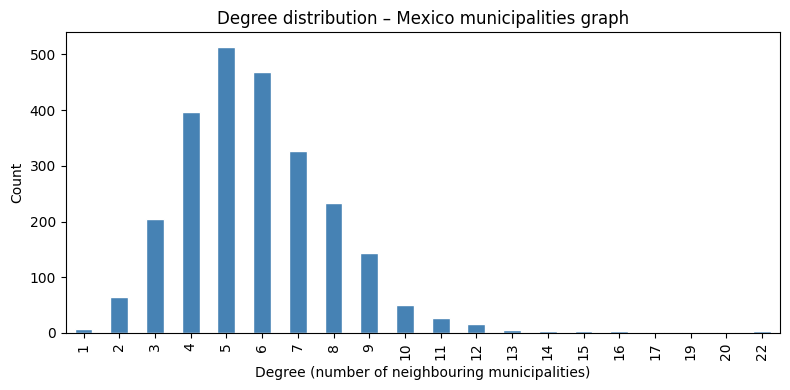

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
deg_series.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Degree (number of neighbouring municipalities)")
ax.set_ylabel("Count")
ax.set_title("Degree distribution – Mexico municipalities graph")
plt.tight_layout()
plt.show()

## 5 · Geographic layout – node positions from centroid coordinates

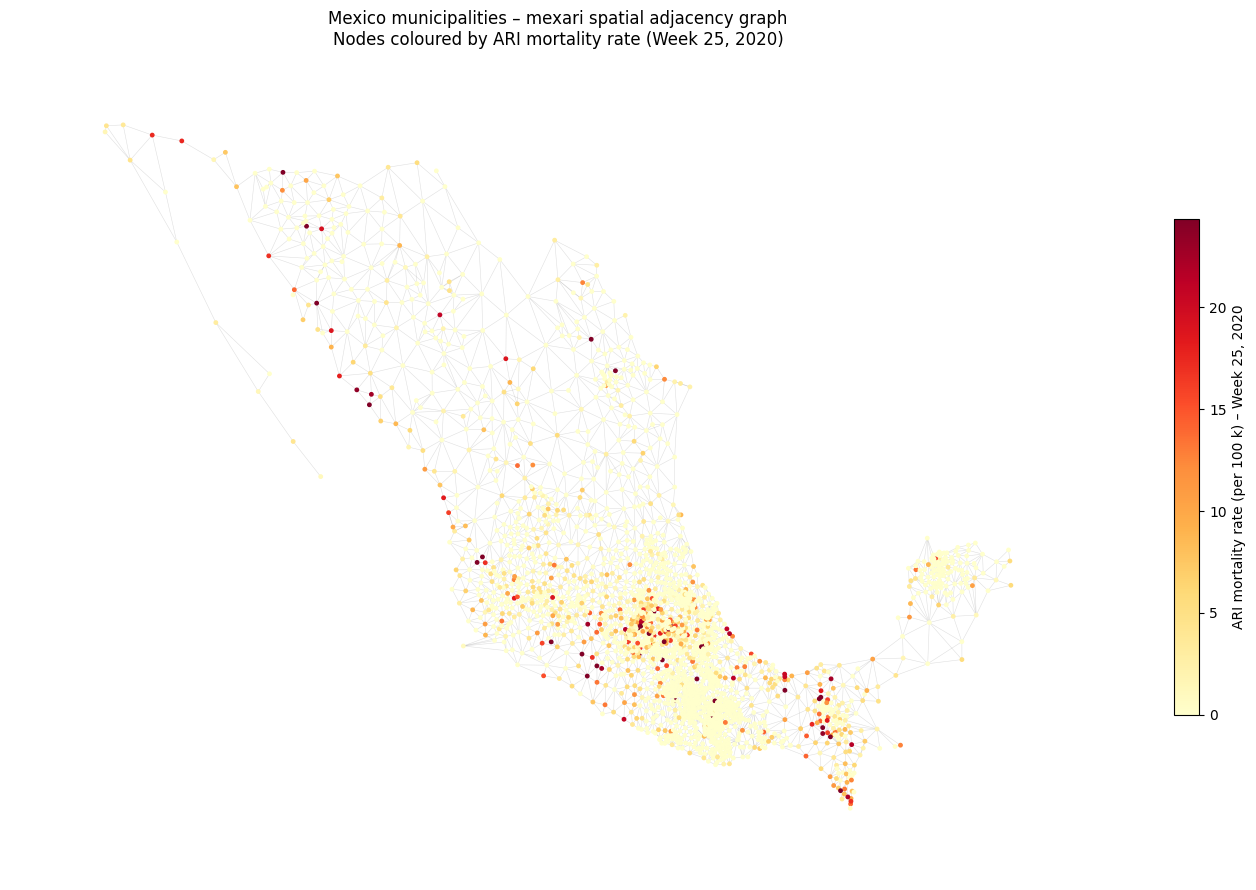

In [30]:
pos = {n: (G.nodes[n]["lon"], G.nodes[n]["lat"]) for n in G.nodes()}

mortality_values = [G.nodes[n]["mortality"].get("2020/25", 0.0) for n in G.nodes()]
mortality_array = np.array(mortality_values)

fig, ax = plt.subplots(figsize=(14, 9))

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, edge_color="gray", width=0.4)
nc = nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=6,
    node_color=mortality_array,
    cmap=plt.cm.YlOrRd,
    vmin=0,
    vmax=float(np.percentile(mortality_array[mortality_array > 0], 95))
    if (mortality_array > 0).any() else 1,
)
plt.colorbar(nc, ax=ax, label="ARI mortality rate (per 100 k) – Week 25, 2020", shrink=0.6)
ax.set_title(
    "Mexico municipalities – mexari spatial adjacency graph\n"
    "Nodes coloured by ARI mortality rate (Week 25, 2020)"
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 6 · GNN-ready tensors – node feature matrix and edge index

In [31]:
X, node_order = mx.get_node_feature_matrix(G)
edge_index = mx.get_edge_index(G, node_order)

print(f"Node feature matrix  X  : {X.shape}  (nodes × time steps)")
print(f"Edge index              : {edge_index.shape}  (2 × num_directed_edges)")
print(f"\nFirst 5 nodes : {node_order[:5]}")
print(f"Features for '{node_order[0]}' : {X[0]}")

Node feature matrix  X  : (2475, 1148)  (nodes × time steps)
Edge index              : (2, 14492)  (2 × num_directed_edges)

First 5 nodes : ['01008', '01009', '01010', '01011', '01001']
Features for '01008' : [0. 0. 0. ... 0. 0. 0.]
